# CNN Training Notebook

This notebook prepares the UTKFace dataset, trains a CNN-based adult/minor classifier, fine-tunes the model, evaluates it, and saves training history.

In [2]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

PROJECT_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / 'data').exists() and (candidate / 'Model').exists()
    ),
    Path.cwd(),
)


In [3]:
CONFIG = {
    'base_path': str(PROJECT_ROOT / 'data'),
    'dataset_folder': 'Face_Age_Dataset',
    'image_size': (128, 128),
    'batch_size': 32,
    'initial_epochs': 20,
    'fine_tune_epochs': 15,
    'fine_tune_at': 100,
    'adult_age': 21,
    'random_state': 42,
    'training_output_dir': str(PROJECT_ROOT / 'Model' / 'CNN' / 'runs' / 'cnn_age_detector'),
    'base_model_output': 'best_age_model.h5',
    'fine_tuned_model_output': 'best_age_model_finetuned.h5',
}

CONFIG


{'base_path': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\data',
 'dataset_folder': 'Face_Age_Dataset',
 'image_size': (128, 128),
 'batch_size': 32,
 'initial_epochs': 20,
 'fine_tune_epochs': 15,
 'fine_tune_at': 100,
 'adult_age': 18,
 'random_state': 42,
 'training_output_dir': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\Model\\CNN\\runs\\cnn_age_detector',
 'base_model_output': 'best_age_model.h5',
 'fine_tuned_model_output': 'best_age_model_finetuned.h5'}

In [4]:
def check_env():
    print('TensorFlow version:', tf.__version__)
    print('Available GPU devices:', tf.config.list_physical_devices('GPU'))


def load_and_parse_data(base_path, dataset_folder='Face_Age_Dataset', adult_age=18):
    dataset_path = Path(base_path) / dataset_folder
    if not dataset_path.exists():
        print(f'Error: path does not exist: {dataset_path}')
        return pd.DataFrame()

    records = []

    for image_path in dataset_path.rglob('*'):
        if not image_path.is_file() or image_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}:
            continue

        stem_parts = image_path.stem.rsplit('_', 1)
        if len(stem_parts) != 2 or not stem_parts[1].isdigit():
            continue

        age = int(stem_parts[1])
        if not (0 <= age <= 120):
            continue

        records.append({
            'path': str(image_path),
            'age': age,
            'is_adult': age >= adult_age,
            'source_group': image_path.parent.name,
        })

    df = pd.DataFrame(records)
    if df.empty:
        return df

    bins = [0, 12, 17, 25, 45, 120]
    labels = ['Child(0-12)', 'Teen(13-17)', 'Young(18-25)', 'Adult(26-45)', 'Senior(46+)']
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
    return df


def visualize_dataset(df):
    if df.empty:
        print('Dataset is empty. Nothing to visualize.')
        return

    sns.set_theme(style='whitegrid')

    plt.figure(figsize=(12, 6))
    sns.histplot(df['age'], bins=range(0, 101), kde=True, color='teal')
    plt.axvline(x=18, color='red', linestyle='--', label='Adult threshold')
    plt.title('Face Age Dataset Distribution')
    plt.xlabel('Age')
    plt.ylabel('Image Count')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    fig, axes = plt.subplots(3, 1, figsize=(16, 10))
    sns.histplot(df['age'], bins=30, kde=True, color='#1f77b4', ax=axes[0])
    axes[0].set_title('Age Distribution')

    sns.countplot(data=df, x='source_group', hue='source_group', ax=axes[1], legend=False)
    axes[1].set_title('Source Folder Distribution')

    sns.countplot(data=df, x='is_adult', order=[True, False], hue='is_adult', ax=axes[2], legend=False)
    axes[2].set_title('Adult vs Minor Distribution')

    plt.tight_layout()
    plt.show()


def resample_dataset(df):
    if df.empty:
        return df

    df_teen = df[df['age_group'] == 'Teen(13-17)']
    child_n = min(1000, len(df[df['age_group'] == 'Child(0-12)']))
    young_n = min(1200, len(df[df['age_group'] == 'Young(18-25)']))
    adult_n = min(1500, len(df[df['age_group'] == 'Adult(26-45)']))
    senior_n = min(500, len(df[df['age_group'] == 'Senior(46+)']))

    df_child = df[df['age_group'] == 'Child(0-12)'].sample(child_n, random_state=42)
    df_young = df[df['age_group'] == 'Young(18-25)'].sample(young_n, random_state=42)
    df_adult = df[df['age_group'] == 'Adult(26-45)'].sample(adult_n, random_state=42)
    df_senior = df[df['age_group'] == 'Senior(46+)'].sample(senior_n, random_state=42)

    final_df = pd.concat([df_child, df_teen, df_young, df_adult, df_senior]).reset_index(drop=True)
    print('Balanced dataset label counts:')
    print(final_df['is_adult'].value_counts())
    return final_df


class HistorySaver(Callback):
    def __init__(self, output_dir, stage_name):
        super().__init__()
        self.output_dir = Path(output_dir)
        self.stage_name = stage_name
        self.records = []
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        record = {'epoch': int(epoch + 1), 'stage': self.stage_name}
        for key, value in logs.items():
            record[key] = float(value)
        self.records.append(record)

        csv_path = self.output_dir / f'{self.stage_name}_history.csv'
        json_path = self.output_dir / f'{self.stage_name}_history.json'
        pd.DataFrame(self.records).to_csv(csv_path, index=False)
        with json_path.open('w', encoding='utf-8') as file:
            json.dump(self.records, file, indent=2)


TensorFlow version: 2.10.0
Available GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Total parsed rows: 31780


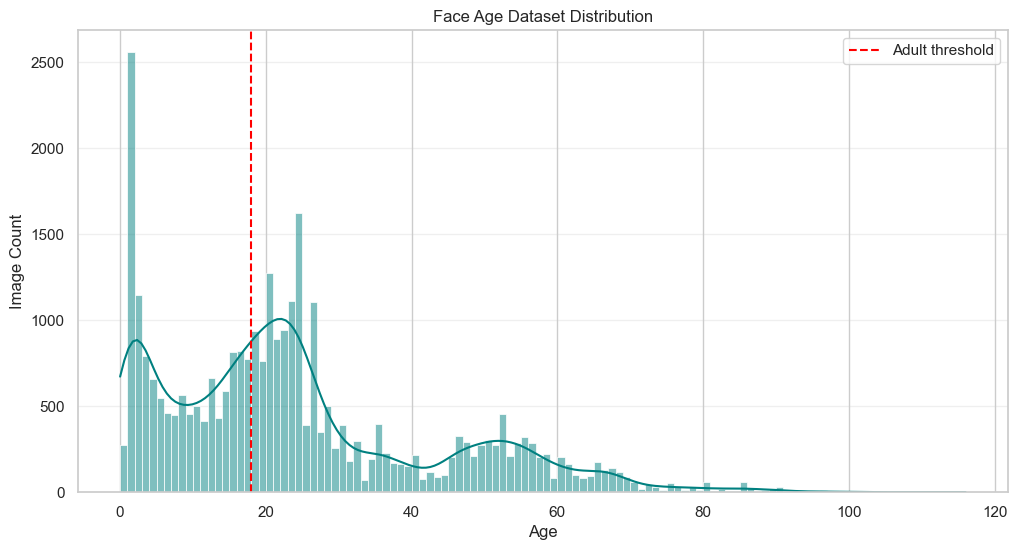

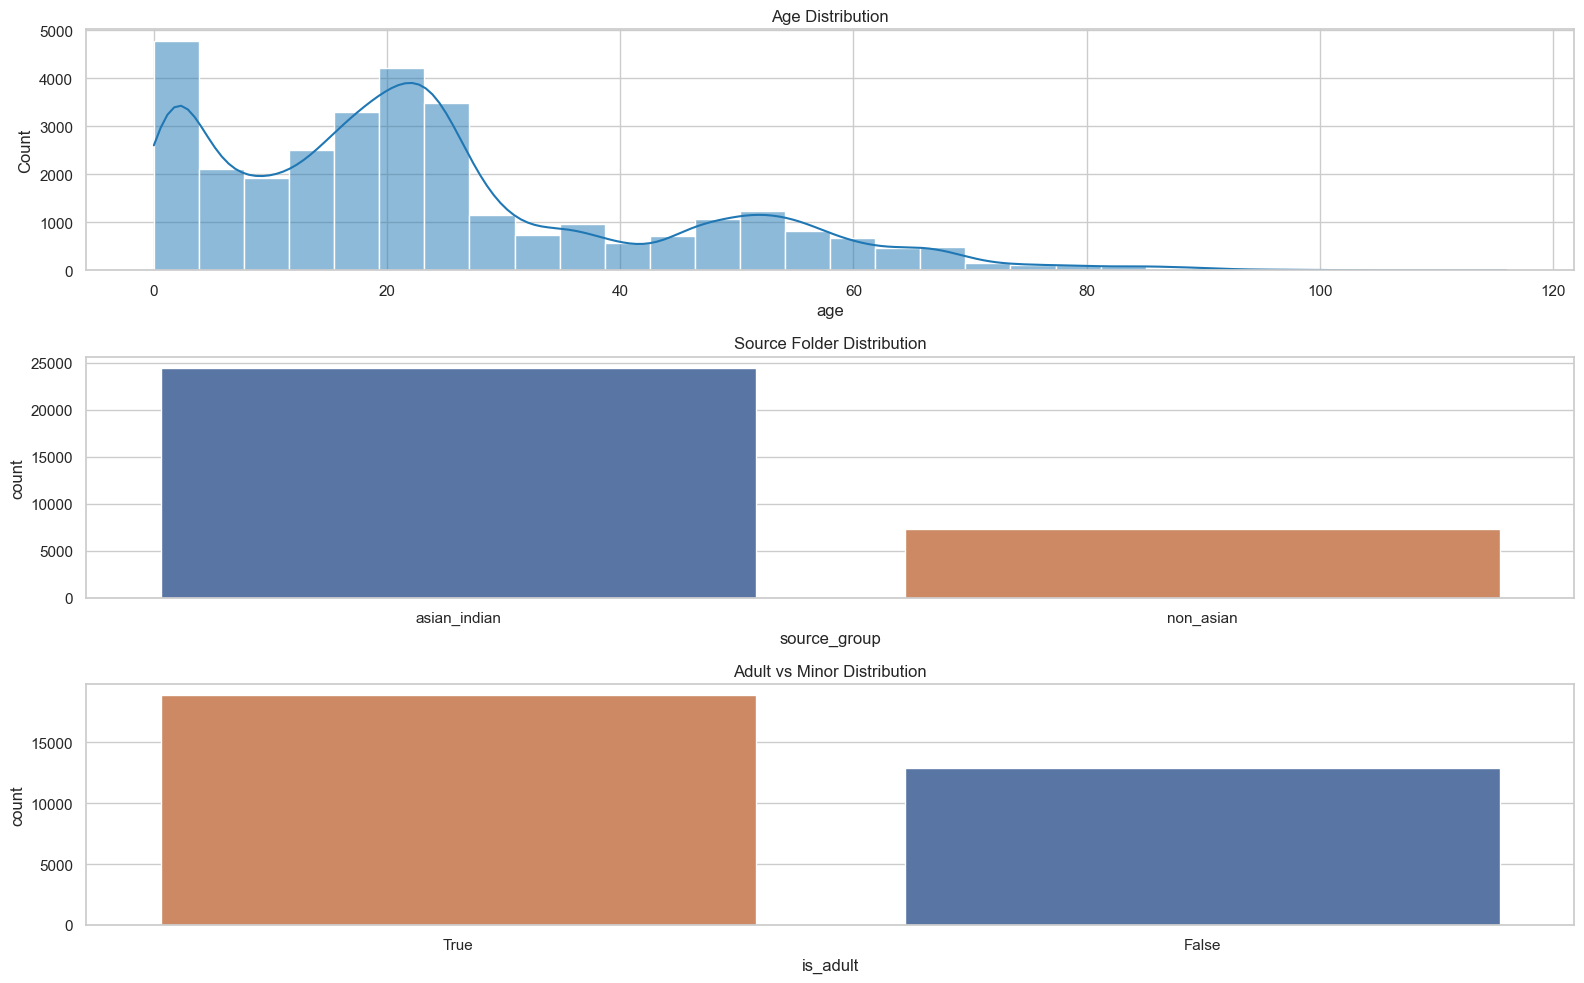

Balanced dataset label counts:
is_adult
False    4432
True     3200
Name: count, dtype: int64
Train: 6105 | Validation: 763 | Test: 764
Found 6105 validated image filenames.
Found 763 validated image filenames.
Found 764 validated image filenames.


In [5]:
check_env()

output_dir = Path(CONFIG['training_output_dir'])
output_dir.mkdir(parents=True, exist_ok=True)

raw_df = load_and_parse_data(
    CONFIG['base_path'],
    dataset_folder=CONFIG['dataset_folder'],
    adult_age=CONFIG['adult_age'],
)
print(f'Total parsed rows: {len(raw_df)}')

visualize_dataset(raw_df)

final_df = resample_dataset(raw_df)
train_df, temp_df = train_test_split(
    final_df,
    test_size=0.2,
    stratify=final_df['is_adult'],
    random_state=CONFIG['random_state'],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['is_adult'],
    random_state=CONFIG['random_state'],
)

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='is_adult',
    target_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='raw',
)
val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='is_adult',
    target_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='raw',
)
test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='is_adult',
    target_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='raw',
    shuffle=False,
)

with (output_dir / 'split_summary.json').open('w', encoding='utf-8') as file:
    json.dump(
        {
            'config': {key: list(value) if isinstance(value, tuple) else value for key, value in CONFIG.items()},
            'raw_rows': int(len(raw_df)),
            'final_rows': int(len(final_df)),
            'train_rows': int(len(train_df)),
            'val_rows': int(len(val_df)),
            'test_rows': int(len(test_df)),
        },
        file,
        indent=2,
    )


In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(CONFIG['image_size'][0], CONFIG['image_size'][1], 3),
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid'),
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


9406464/9406464 [==============================] - 2s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_128 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                           

## Stage 1: Initial Training

In [7]:
initial_history_saver = HistorySaver(output_dir, 'initial_training')
initial_callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(output_dir / CONFIG['base_model_output']), monitor='val_loss', save_best_only=True, verbose=1),
    initial_history_saver,
]

print('Starting initial training...')
history_initial = model.fit(
    train_generator,
    epochs=CONFIG['initial_epochs'],
    validation_data=val_generator,
    callbacks=initial_callbacks,
)


Starting initial training...
Epoch 1/20
191/191 [==============================] - ETA: 0s - loss: 0.5926 - accuracy: 0.7048
Epoch 1: val_loss improved from inf to 0.51129, saving model to D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\CNN\runs\cnn_age_detector\best_age_model.h5
191/191 [==============================] - 101s 514ms/step - loss: 0.5926 - accuracy: 0.7048 - val_loss: 0.5113 - val_accuracy: 0.7746
Epoch 2/20
191/191 [==============================] - ETA: 0s - loss: 0.5306 - accuracy: 0.7479
Epoch 2: val_loss improved from 0.51129 to 0.49318, saving model to D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\CNN\runs\cnn_age_detector\best_age_model.h5
191/191 [==============================] - 12s 64ms/step - loss: 0.5306 - accuracy: 0.7479 - val_loss: 0.4932 - val_accuracy: 0.7903
Epoch 3/20
191/191 [==============================] - ETA: 0s - loss: 0.5172 - accuracy: 0.7505
Epoch 3: val_loss improved fr

## Stage 2: Fine-Tuning

In [8]:
print('Preparing fine-tuning...')
base_model.trainable = True
print(f'MobileNetV2 layer count: {len(base_model.layers)}')

for layer in base_model.layers[:CONFIG['fine_tune_at']]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

fine_tune_history_saver = HistorySaver(output_dir, 'fine_tuning')
fine_tune_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(output_dir / CONFIG['fine_tuned_model_output']), monitor='val_loss', save_best_only=True, verbose=1),
    fine_tune_history_saver,
]

history_fine_tune = model.fit(
    train_generator,
    epochs=CONFIG['fine_tune_epochs'],
    validation_data=val_generator,
    callbacks=fine_tune_callbacks,
)


Preparing fine-tuning...
MobileNetV2 layer count: 154
Epoch 1/15
191/191 [==============================] - ETA: 0s - loss: 0.5894 - accuracy: 0.7084
Epoch 1: val_loss improved from inf to 0.48339, saving model to D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\CNN\runs\cnn_age_detector\best_age_model_finetuned.h5
191/191 [==============================] - 15s 66ms/step - loss: 0.5894 - accuracy: 0.7084 - val_loss: 0.4834 - val_accuracy: 0.7969
Epoch 2/15
191/191 [==============================] - ETA: 0s - loss: 0.5184 - accuracy: 0.7548
Epoch 2: val_loss improved from 0.48339 to 0.47816, saving model to D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\CNN\runs\cnn_age_detector\best_age_model_finetuned.h5
191/191 [==============================] - 12s 64ms/step - loss: 0.5184 - accuracy: 0.7548 - val_loss: 0.4782 - val_accuracy: 0.8047
Epoch 3/15
191/191 [==============================] - ETA: 0s - loss: 0.4855 - acc

## Evaluation

24/24 [==============================] - 10s 410ms/step - loss: 0.4691 - accuracy: 0.7919
Test accuracy after fine-tuning: 79.19%
24/24 [==============================] - 1s 29ms/step


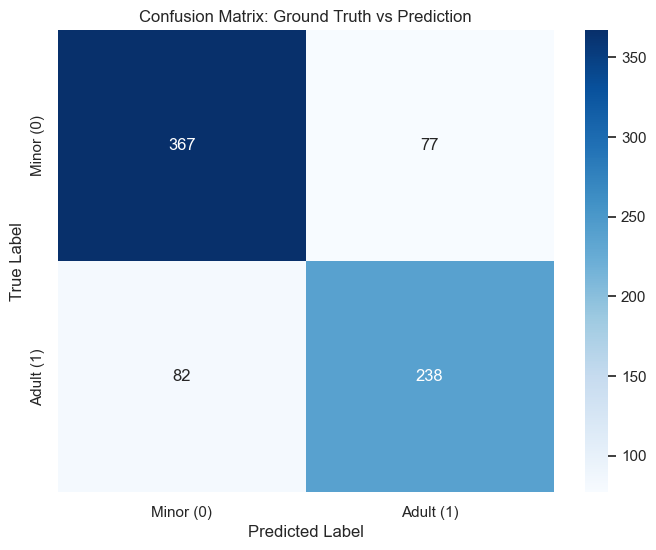

              precision    recall  f1-score   support

   Minor (0)       0.82      0.83      0.82       444
   Adult (1)       0.76      0.74      0.75       320

    accuracy                           0.79       764
   macro avg       0.79      0.79      0.79       764
weighted avg       0.79      0.79      0.79       764



In [9]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'Test accuracy after fine-tuning: {test_acc * 100:.2f}%')

y_true = test_df['is_adult'].astype(int).values
y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Minor (0)', 'Adult (1)'],
    yticklabels=['Minor (0)', 'Adult (1)'],
)
plt.title('Confusion Matrix: Ground Truth vs Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(y_true, y_pred, target_names=['Minor (0)', 'Adult (1)']))


In [10]:
combined_history = pd.concat(
    [pd.DataFrame(initial_history_saver.records), pd.DataFrame(fine_tune_history_saver.records)],
    ignore_index=True,
)
combined_history.to_csv(output_dir / 'combined_history.csv', index=False)
combined_history


,epoch,stage,loss,accuracy,val_loss,val_accuracy
0,1,initial_training,0.592650,0.704832,0.511289,0.774574
1,2,initial_training,0.530631,0.747912,0.493182,0.790301
2,3,initial_training,0.517187,0.750532,0.488371,0.758847
3,4,initial_training,0.498678,0.762490,0.486734,0.782438
4,5,initial_training,0.491502,0.769533,0.469233,0.779817
5,6,initial_training,0.487806,0.771990,0.477503,0.771953
6,7,initial_training,0.483821,0.772154,0.475961,0.788991
7,8,initial_training,0.474268,0.778051,0.477769,0.779817
8,9,initial_training,0.475906,0.781163,0.483234,0.777195
9,1,fine_tuning,0.589447,0.708436,0.483388,0.796855
